In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers, constraints, initializers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# Keeping the seed fixed so the results stay reproducible
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Loading the tabular dataset from the student wellness dataset
tabular_base_path = "/content/drive/MyDrive/student_wellness_multimodal_dataset/student_wellness_multimodal_dataset/tabular"

train_tabular_path = os.path.join(tabular_base_path, "train.csv")
test_tabular_path = os.path.join(tabular_base_path, "test.csv")

train_tabular_df = pd.read_csv(train_tabular_path)
test_tabular_df = pd.read_csv(test_tabular_path)

print("Train shape:", train_tabular_df.shape)
print("Test shape:", test_tabular_df.shape)
train_tabular_df.head()

Train shape: (240, 13)
Test shape: (80, 13)


,sample_id,sleep_hours,study_hours,attendance_pct,stress_score,caffeine_cups,exercise_minutes,screen_time_hours,assignment_delay_days,social_minutes,mood_score,label,label_id
0,train_0000,8.18,1.46,96.50,29.41,0.00,31.98,4.65,0.18,59.80,7.15,low_risk,0
1,train_0001,7.33,4.78,85.40,56.27,2.13,21.41,6.44,0.54,55.54,6.25,moderate_risk,1
2,train_0002,5.49,4.82,84.34,68.45,2.50,14.48,8.14,3.57,34.95,4.93,high_risk,2
3,train_0003,5.88,6.09,64.93,79.86,4.23,19.29,8.86,4.16,5.11,3.65,critical_risk,3
4,train_0004,8.45,3.04,88.01,22.32,1.08,47.19,5.55,0.72,68.15,8.07,low_risk,0


In [4]:
# Turning the label names into numeric classes
label_to_index = {
    label: idx for idx, label in enumerate(sorted(train_tabular_df["label"].unique()))
}

index_to_label = {idx: label for label, idx in label_to_index.items()}

train_tabular_df["label_id"] = train_tabular_df["label"].map(label_to_index)
test_tabular_df["label_id"] = test_tabular_df["label"].map(label_to_index)

print(label_to_index)

{'critical_risk': 0, 'high_risk': 1, 'low_risk': 2, 'moderate_risk': 3}


In [5]:
# Keeping only numeric feature columns
excluded_columns = ["label", "label_id"]

numeric_feature_columns = [
    col for col in train_tabular_df.columns
    if col not in excluded_columns and pd.api.types.is_numeric_dtype(train_tabular_df[col])
]

print("Numeric feature columns:")
print(numeric_feature_columns)

Numeric feature columns:
['sleep_hours', 'study_hours', 'attendance_pct', 'stress_score', 'caffeine_cups', 'exercise_minutes', 'screen_time_hours', 'assignment_delay_days', 'social_minutes', 'mood_score']


In [6]:
# Preparing train, validation, and test sets
X_train_full = train_tabular_df[numeric_feature_columns].values
y_train_full = train_tabular_df["label_id"].values

X_test = test_tabular_df[numeric_feature_columns].values
y_test = test_tabular_df["label_id"].values

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (192, 10)
Validation shape: (48, 10)
Test shape: (80, 10)


In [7]:
# This is my custom activation function, inspired by leaky behavior
def my_leaky_activation(x):
    return tf.where(x > 0.0, x, 0.1 * x)

In [8]:
# This is my custom initializer
class MyGlorotInitializer(initializers.Initializer):
    def __call__(self, shape, dtype=None):
        stddev = tf.sqrt(2.0 / tf.cast(shape[0] + shape[1], tf.float32))
        return tf.random.normal(shape, stddev=stddev, dtype=dtype)

    def get_config(self):
        return {}

In [9]:
# This is my custom L1 regularizer
class MyL1Regularizer(regularizers.Regularizer):
    def __init__(self, factor=1e-4):
        self.factor = factor

    def __call__(self, x):
        return self.factor * tf.reduce_sum(tf.abs(x))

    def get_config(self):
        return {"factor": self.factor}

In [10]:
# This custom constraint keeps weights non-negative
class MyPositiveWeights(constraints.Constraint):
    def __call__(self, w):
        return tf.maximum(w, 0.0)

In [11]:
# This is my custom loss function, based on Huber-style behavior
class MyHuberLoss(keras.losses.Loss):
    def __init__(self, threshold=1.0, name="my_huber_loss"):
        super().__init__(name=name)
        self.threshold = threshold

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.one_hot(tf.cast(y_true, tf.int32), depth=len(label_to_index)), tf.float32)
        error = y_true - y_pred
        abs_error = tf.abs(error)
        quadratic = tf.minimum(abs_error, self.threshold)
        linear = abs_error - quadratic
        return tf.reduce_mean(0.5 * tf.square(quadratic) + self.threshold * linear)

    def get_config(self):
        return {"threshold": self.threshold}

In [12]:
# This is my custom accuracy metric
class MyAccuracyMetric(keras.metrics.Metric):
    def __init__(self, name="my_accuracy", **kwargs):
        super().__init__(name=name, **kwargs)
        self.correct = self.add_weight(name="correct", initializer="zeros")
        self.total = self.add_weight(name="total", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_classes = tf.argmax(y_pred, axis=1, output_type=tf.int32)
        y_true = tf.cast(y_true, tf.int32)

        matches = tf.cast(tf.equal(y_true, y_pred_classes), tf.float32)
        self.correct.assign_add(tf.reduce_sum(matches))
        self.total.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.correct / self.total

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

In [13]:
# This is a regular baseline model for comparison
def build_baseline_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [14]:
# This model uses the custom activation, initializer, regularizer, and constraint
def build_custom_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(
            64,
            activation=my_leaky_activation,
            kernel_initializer=MyGlorotInitializer(),
            kernel_regularizer=MyL1Regularizer(1e-4),
            kernel_constraint=MyPositiveWeights()
        ),
        layers.Dropout(0.2),
        layers.Dense(
            32,
            activation=my_leaky_activation,
            kernel_initializer=MyGlorotInitializer(),
            kernel_regularizer=MyL1Regularizer(1e-4),
            kernel_constraint=MyPositiveWeights()
        ),
        layers.Dense(len(label_to_index), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss=MyHuberLoss(threshold=1.0),
        metrics=[MyAccuracyMetric()]
    )
    return model

In [15]:
# Training the baseline model
baseline_model = build_baseline_model(X_train.shape[1])

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(X_test, y_test, verbose=0)
print("Baseline Test Accuracy:", round(baseline_test_acc, 4))

Baseline Test Accuracy: 0.925


In [16]:
# Training the custom model
custom_model = build_custom_model(X_train.shape[1])

history_custom = custom_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=0
)

custom_test_loss, custom_test_metric = custom_model.evaluate(X_test, y_test, verbose=0)
print("Custom Model Test Metric:", round(custom_test_metric, 4))

Custom Model Test Metric: 0.95


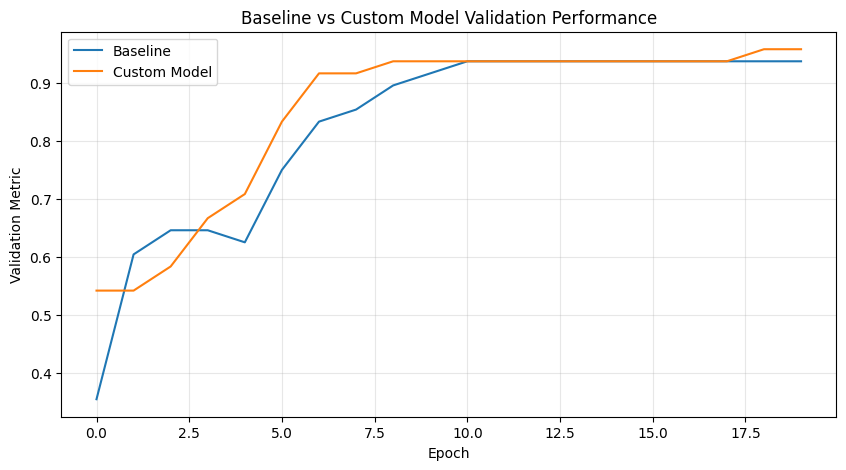

In [17]:
# Comparing the validation curves for the baseline and custom model
baseline_val_key = "val_accuracy"
custom_val_key = "val_my_accuracy"

plt.figure(figsize=(10, 5))
plt.plot(history_baseline.history[baseline_val_key], label="Baseline")
plt.plot(history_custom.history[custom_val_key], label="Custom Model")
plt.title("Baseline vs Custom Model Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Validation Metric")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Looking at a few predictions from the custom model
sample_predictions = custom_model.predict(X_test[:8], verbose=0)
predicted_classes = np.argmax(sample_predictions, axis=1)

for i in range(8):
    print("True Label     :", index_to_label[y_test[i]])
    print("Predicted Label:", index_to_label[predicted_classes[i]])
    print("-" * 50)

True Label     : low_risk
Predicted Label: low_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------
True Label     : low_risk
Predicted Label: low_risk
--------------------------------------------------
True Label     : critical_risk
Predicted Label: critical_risk
--------------------------------------------------
True Label     : high_risk
Predicted Label: high_risk
--------------------------------------------------
True Label     : moderate_risk
Predicted Label: moderate_risk
--------------------------------------------------


In [19]:
# Final summary so the comparison is easy to explain in the video
print("Colab 7 Results Summary")
print("-" * 45)
print(f"Baseline Model Accuracy : {baseline_test_acc:.4f}")
print(f"Custom Model Metric     : {custom_test_metric:.4f}")

Colab 7 Results Summary
---------------------------------------------
Baseline Model Accuracy : 0.9250
Custom Model Metric     : 0.9500


### Final Observation

In this notebook, I focused on custom deep learning building blocks in TensorFlow. I created a custom activation function, initializer, regularizer, weight constraint, loss function, and metric, and then used them together inside one custom tabular classification model. I compared this custom model with a regular baseline model to see how these custom design choices affect training and validation behavior.